# v4-data — Data section notebook

This notebook builds **data explanatory tables and graphs** for the thesis.

It prioritises the main-text package and also generates appendix diagnostics.

**Inputs (automatic):**
- `Data/Clean/Final-v4.csv`
- `v4-simulation.xlsx` (if available; used for simulation-specific baseline objects)

**Outputs:**
- Tables displayed in-notebook
- Figures saved in `imgs/v4-data/`

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from ast import literal_eval

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)

ROOT = Path('.')
CSV_PATH = ROOT / 'Data/Clean/Final-v4.csv'
XLSX_PATH = ROOT / 'v4-simulation.xlsx'
OUT_DIR = ROOT / 'imgs' / 'v4-data'
OUT_DIR.mkdir(parents=True, exist_ok=True)

assert CSV_PATH.exists(), f'Missing file: {CSV_PATH}'

df_raw = pd.read_csv(CSV_PATH)
xls = pd.ExcelFile(XLSX_PATH) if XLSX_PATH.exists() else None

def read_sheet(name):
    if xls is not None and name in xls.sheet_names:
        return pd.read_excel(XLSX_PATH, sheet_name=name)
    return None

config = read_sheet('Config')
macro = read_sheet('Macro_Variables')
portfolio_data_sheet = read_sheet('Portfolio_Data')

def parse_csv_list(x):
    if pd.isna(x):
        return []
    s = str(x).strip()
    if s.startswith('[') and s.endswith(']'):
        try:
            return [str(v).strip().strip("'").strip('"') for v in literal_eval(s)]
        except Exception:
            pass
    return [p.strip() for p in s.split(',') if p.strip()]

if config is not None:
    cfg = dict(zip(config['parameter'], config['value']))
    EU27 = parse_csv_list(cfg.get('EU27', ''))
    OUTSIDE = parse_csv_list(cfg.get('OUTSIDE', ''))
    FINANCIAL_CENTRES = set(parse_csv_list(cfg.get('FINANCIAL_CENTRES', 'IRL, LUX, CYP, MLT')))
    base_year_cfg = int(cfg.get('BASE_YEAR', 2019))
else:
    EU27 = ['AUT','BEL','BGR','CYP','CZE','DNK','EST','FIN','FRA','DEU','GRC','HUN','IRL','ITA','LVA','LTU','LUX','MLT','NLD','POL','PRT','ROU','SVK','SVN','ESP','SWE']
    OUTSIDE = ['GBR','CHE','NOR']
    FINANCIAL_CENTRES = {'IRL', 'LUX', 'CYP', 'MLT'}
    base_year_cfg = 2019

if macro is not None and 'country' in macro.columns:
    SIM_COUNTRIES = macro['country'].dropna().astype(str).tolist()
else:
    SIM_COUNTRIES = sorted(set(df_raw['iso3_i']).intersection(set(df_raw['iso3_j'])))

raw_years = sorted(df_raw['year'].dropna().astype(int).unique().tolist())
BASE_YEAR = 2023 if 2023 in raw_years else (base_year_cfg if base_year_cfg in raw_years else raw_years[-1])

print(f'Loaded rows: {len(df_raw):,}')
print(f'Countries in simulation set: {len(SIM_COUNTRIES)}')
print(f'Base year used in this notebook: {BASE_YEAR}')
print(f'Excel available: {XLSX_PATH.exists()}')
print(f'Output folder: {OUT_DIR}')

# Filter to simulation country set
df_country = df_raw[df_raw['iso3_i'].isin(SIM_COUNTRIES) & df_raw['iso3_j'].isin(SIM_COUNTRIES)].copy()
print(f'Observations in simulation country set: {len(df_country):,}')


Loaded rows: 1,535,274
Countries in simulation set: 29
Base year used in this notebook: 2023
Excel available: True
Output folder: imgs/v4-data
Observations in simulation country set: 21,866


In [2]:
# Build filtered samples and helper objects

# Compute d_financial_development_index if not present
if 'd_financial_development_index' not in df_country.columns and 'financial_development_index_i' in df_country.columns:
    df_country['d_financial_development_index'] = np.abs(
        df_country['financial_development_index_i'] - df_country['financial_development_index_j']
    )

ppml_cols = [
    'a_ij', 'd_ling', 'd_num_articles', 'd_geo', 'year', 'iso3_i', 'iso3_j', 'Y_i', 'Y_j'
]
if 'd_financial_development_index' in df_country.columns:
    ppml_cols.append('d_financial_development_index')

df_country['a_ij_raw'] = df_country['a_ij']
neg_before = int((df_country['a_ij_raw'] < 0).sum())
df_country['a_ij'] = df_country['a_ij'].clip(lower=0)
neg_after = int((df_country['a_ij'] < 0).sum())

df_ppml = df_country[df_country['iso3_i'] != df_country['iso3_j']].copy()
raw_ppml_obs = len(df_ppml)
# Only drop if the required columns exist
ppml_cols_exist = [c for c in ppml_cols if c in df_ppml.columns]
df_ppml = df_ppml.dropna(subset=ppml_cols_exist).copy()

base = df_country[df_country['year'] == BASE_YEAR].copy()
base = base[base['iso3_i'].isin(SIM_COUNTRIES) & base['iso3_j'].isin(SIM_COUNTRIES)].copy()

A = base.pivot_table(index='iso3_i', columns='iso3_j', values='a_ij', aggfunc='mean')
A = A.reindex(index=SIM_COUNTRIES, columns=SIM_COUNTRIES)
s_total = A.sum(axis=1)
Pi_data = A.div(s_total.replace(0, np.nan), axis=0)
home_share = pd.Series(np.diag(Pi_data), index=SIM_COUNTRIES, name='observed_home_share')

domestic_holdings = pd.Series(np.diag(A), index=SIM_COUNTRIES, name='observed_domestic_holdings')
foreign_holdings = (s_total - domestic_holdings).rename('foreign_portfolio_holdings')

if macro is not None and {'country','pi_home_data'}.issubset(macro.columns):
    home_share = macro.set_index('country')['pi_home_data'].reindex(SIM_COUNTRIES)

print(f'Country-filtered observations: {len(df_country):,}')
print(f'PPML observations after i!=j and NA filtering: {len(df_ppml):,}')
print(f'Base-year simulation observations: {len(base):,}')
print(f'Negative holdings before flooring: {neg_before:,} | after flooring: {neg_after:,}')
print(f'PPML columns available: {ppml_cols_exist}')


Country-filtered observations: 21,866
PPML observations after i!=j and NA filtering: 2,858
Base-year simulation observations: 841
Negative holdings before flooring: 8 | after flooring: 0
PPML columns available: ['a_ij', 'd_ling', 'd_num_articles', 'd_geo', 'year', 'iso3_i', 'iso3_j', 'Y_i', 'Y_j', 'd_financial_development_index']


## Main-text package tables

In [3]:
# 1) Data sources and variable mapping table
data_sources_table = pd.DataFrame([
    {
        'source': 'IMF CPIS / PIP bilateral',
        'variable name': 'a_ij (bilateral portfolio holdings)',
        'economic meaning': 'Cross-border portfolio equity/investment from i to j',
        'unit': 'USD million',
        'frequency': 'Annual',
        'years available': f"{df_raw['year'].min():.0f}-{df_raw['year'].max():.0f}",
        'used in gravity model': 'Yes (dependent variable)',
        'used in simulation': 'Yes',
        'transformation applied': 'Negative values floored at 0; log(1+a_ij) used in diagnostics'
    },
    {
        'source': 'IMF PIP total + Eurostat totals',
        'variable name': 'total_pip_million_usd, total_portfolio_million_usd',
        'economic meaning': 'Country-level foreign holdings and total portfolio wealth',
        'unit': 'USD million',
        'frequency': 'Annual',
        'years available': f"{df_raw['year'].min():.0f}-{df_raw['year'].max():.0f}",
        'used in gravity model': 'No',
        'used in simulation': 'Yes',
        'transformation applied': 'Used to reconstruct domestic holdings and home share'
    },
    {
        'source': 'Penn World Tables',
        'variable name': 'Y, k, L, A, alpha',
        'economic meaning': 'GDP, capital, labour, TFP, capital share',
        'unit': 'Index / USD million / persons / shares',
        'frequency': 'Annual',
        'years available': f"{df_raw['year'].min():.0f}-{df_raw['year'].max():.0f}",
        'used in gravity model': 'Y_i, Y_j yes',
        'used in simulation': 'Yes',
        'transformation applied': 'Normalised return R_j = alpha_j * Y_j / k_j and scaling checks'
    },
    {
        'source': 'Chinn–Ito KAOPEN',
        'variable name': 'd_financial_development_index (distance)',
        'economic meaning': 'Hard financial integration friction between i and j',
        'unit': 'Distance (index difference)',
        'frequency': 'Annual',
        'years available': f"{df_raw['year'].min():.0f}-{df_raw['year'].max():.0f}",
        'used in gravity model': 'Yes',
        'used in simulation': 'Yes',
        'transformation applied': 'Used as bilateral wedge component (policy-sensitive)'
    },
    {
        'source': 'CEPII language and geography',
        'variable name': 'd_ling, d_geo',
        'economic meaning': 'Linguistic and geographic frictions',
        'unit': 'Distance metrics',
        'frequency': 'Mostly time-invariant',
        'years available': 'Pair-level',
        'used in gravity model': 'Yes',
        'used in simulation': 'Yes',
        'transformation applied': 'Enter gravity and wedge matrices; treated as immutable frictions'
    },
    {
        'source': 'IntenSE / media coverage',
        'variable name': 'd_num_articles (news distance)',
        'economic meaning': 'Information friction between country pairs',
        'unit': 'Distance (normalised)',
        'frequency': 'Annual',
        'years available': f"{df_raw['year'].min():.0f}-{df_raw['year'].max():.0f}",
        'used in gravity model': 'Yes',
        'used in simulation': 'Yes',
        'transformation applied': 'Policy-sensitive soft wedge in CMU scenarios'
    }
])
display(data_sources_table)

# 2) Sample construction table
raw_countries = len(set(df_raw['iso3_i']).union(set(df_raw['iso3_j'])))
final_countries = len(SIM_COUNTRIES)
eu_count = len([c for c in SIM_COUNTRIES if c in set(EU27)])
noneu_count = final_countries - eu_count
years_span = f"{int(df_country['year'].min())}-{int(df_country['year'].max())}"
total_pairs = final_countries * final_countries
domestic_pairs = final_countries
foreign_pairs = total_pairs - domestic_pairs

sample_construction_table = pd.DataFrame([
    {'metric': 'raw countries', 'value': raw_countries},
    {'metric': 'final countries', 'value': final_countries},
    {'metric': 'EU countries', 'value': eu_count},
    {'metric': 'non-EU countries', 'value': noneu_count},
    {'metric': 'years available', 'value': years_span},
    {'metric': 'base year', 'value': BASE_YEAR},
    {'metric': 'total bilateral pairs (N^2)', 'value': total_pairs},
    {'metric': 'domestic pairs', 'value': domestic_pairs},
    {'metric': 'foreign pairs', 'value': foreign_pairs},
    {'metric': 'raw observations', 'value': len(df_raw)},
    {'metric': 'observations after country filtering', 'value': len(df_country)},
    {'metric': 'observations after missing-value filtering (PPML vars)', 'value': len(df_country.dropna(subset=ppml_cols))},
    {'metric': 'final PPML observations', 'value': len(df_ppml)},
    {'metric': 'final simulation observations (base-year matrix)', 'value': len(base)}
])
display(sample_construction_table)

# 3) Portfolio holdings diagnostic table
a_all = df_country['a_ij_raw']
a_all_clean = df_country['a_ij']
a_pos = a_all_clean[a_all_clean > 0]
portfolio_diag_table = pd.DataFrame([
    {'metric': 'total observations', 'value': int(len(a_all))},
    {'metric': 'positive positions', 'value': int((a_all_clean > 0).sum())},
    {'metric': 'zero positions', 'value': int((a_all_clean == 0).sum())},
    {'metric': 'negative positions before cleaning', 'value': int((a_all < 0).sum())},
    {'metric': 'negative positions after flooring', 'value': int((a_all_clean < 0).sum())},
    {'metric': 'missing positions', 'value': int(a_all_clean.isna().sum())},
    {'metric': 'mean positive holding', 'value': float(a_pos.mean())},
    {'metric': 'median positive holding', 'value': float(a_pos.median())},
    {'metric': 'maximum holding', 'value': float(a_pos.max())},
    {'metric': 'zero share', 'value': float((a_all_clean == 0).mean())}
])
display(portfolio_diag_table)

,source,variable name,economic meaning,unit,frequency,years available,used in gravity model,used in simulation,transformation applied
0,IMF CPIS / PIP bilateral,a_ij (bilateral portfolio holdings),Cross-border portfolio equity/investment from ...,USD million,Annual,2000-2025,Yes (dependent variable),Yes,Negative values floored at 0; log(1+a_ij) used...
1,IMF PIP total + Eurostat totals,"total_pip_million_usd, total_portfolio_million...",Country-level foreign holdings and total portf...,USD million,Annual,2000-2025,No,Yes,Used to reconstruct domestic holdings and home...
2,Penn World Tables,"Y, k, L, A, alpha","GDP, capital, labour, TFP, capital share",Index / USD million / persons / shares,Annual,2000-2025,"Y_i, Y_j yes",Yes,Normalised return R_j = alpha_j * Y_j / k_j an...
3,Chinn–Ito KAOPEN,d_financial_development_index (distance),Hard financial integration friction between i ...,Distance (index difference),Annual,2000-2025,Yes,Yes,Used as bilateral wedge component (policy-sens...
4,CEPII language and geography,"d_ling, d_geo",Linguistic and geographic frictions,Distance metrics,Mostly time-invariant,Pair-level,Yes,Yes,Enter gravity and wedge matrices; treated as i...
5,IntenSE / media coverage,d_num_articles (news distance),Information friction between country pairs,Distance (normalised),Annual,2000-2025,Yes,Yes,Policy-sensitive soft wedge in CMU scenarios


,metric,value
0,raw countries,243
1,final countries,29
2,EU countries,26
3,non-EU countries,3
4,years available,2000-2025
5,base year,2023
6,total bilateral pairs (N^2),841
7,domestic pairs,29
8,foreign pairs,812
9,raw observations,1535274


,metric,value
0,total observations,2.186600e+04
1,positive positions,1.744500e+04
2,zero positions,4.860000e+02
3,negative positions before cleaning,8.000000e+00
4,negative positions after flooring,0.000000e+00
5,missing positions,3.935000e+03
6,mean positive holding,1.912756e+04
7,median positive holding,6.387036e+02
8,maximum holding,1.097544e+06
9,zero share,2.222629e-02


In [4]:
# 7) Country-level baseline table
if macro is not None and 'country' in macro.columns:
    country_baseline_table = macro[['country']].copy()
    keep_map = {
        'GDP_USDmn': 'GDP',
        'k_PWT_USDmn': 'capital_stock',
        'L_labour': 'labour',
        'A_bar': 'TFP',
        'alpha': 'capital_share',
        'R_normalised': 'normalised_return',
        's_total_wealth': 'total_portfolio_wealth',
        'pi_home_data': 'observed_home_share',
        'f_foreign_intensity': 'foreign_capital_intensity',
    }
    for c0, c1 in keep_map.items():
        country_baseline_table[c1] = macro[c0] if c0 in macro.columns else np.nan
else:
    cbase = base.drop_duplicates('iso3_i').set_index('iso3_i').reindex(SIM_COUNTRIES)
    country_baseline_table = pd.DataFrame({
        'country': SIM_COUNTRIES,
        'GDP': cbase['Y_i'].values,
        'capital_stock': cbase['k_i'].values,
        'labour': cbase['L_i'].values,
        'TFP': cbase['A_i'].values,
        'capital_share': cbase['alpha_i'].values,
        'normalised_return': ((cbase['alpha_i'] * cbase['Y_i'] / cbase['k_i']) / (cbase['alpha_i'] * cbase['Y_i'] / cbase['k_i']).mean()).values,
        'total_portfolio_wealth': s_total.reindex(SIM_COUNTRIES).values,
        'observed_home_share': home_share.reindex(SIM_COUNTRIES).values,
        'foreign_capital_intensity': np.nan,
    })

country_baseline_table['EU_indicator'] = country_baseline_table['country'].isin(EU27).astype(int)
country_baseline_table['financial_centre_indicator'] = country_baseline_table['country'].isin(FINANCIAL_CENTRES).astype(int)
country_baseline_table = country_baseline_table[['country','EU_indicator','financial_centre_indicator','GDP','capital_stock','labour','TFP','capital_share','normalised_return','total_portfolio_wealth','observed_home_share','foreign_capital_intensity']]
display(country_baseline_table.round(4))

# 8) Home-bias country table
def calibration_status(c, hs):
    if c in FINANCIAL_CENTRES:
        return 0, 'Financial centre (set neutral)'
    if pd.isna(hs) or hs <= 0 or hs >= 0.9999:
        return 0, 'Invalid or missing observed home share'
    return 1, 'Used in diagonal calibration'

home_bias_rows = []
for c in SIM_COUNTRIES:
    hs = home_share.get(c, np.nan)
    used, reason = calibration_status(c, hs)
    home_bias_rows.append({
        'country': c,
        'observed domestic holdings': domestic_holdings.get(c, np.nan),
        'total portfolio wealth': s_total.get(c, np.nan),
        'foreign portfolio holdings': foreign_holdings.get(c, np.nan),
        'observed home share': hs,
        'used in diagonal calibration': used,
        'reason if not used': reason if used == 0 else ''
    })
home_bias_table = pd.DataFrame(home_bias_rows)
home_bias_table = home_bias_table.sort_values('observed home share', ascending=False, na_position='last')
display(home_bias_table.round(4))

# 9) Friction summary table
fric_specs = [
    ('d_ling', 'Linguistic distance', 'Cultural/information', 'Fixed (immutable)', 'distance index'),
    ('d_num_articles', 'News/informational distance', 'Information', 'Policy-sensitive', 'distance index'),
    ('d_financial_development_index', 'Capital-account-openness distance', 'Financial', 'Policy-sensitive', 'distance index'),
    ('d_geo', 'Geographic distance', 'Physical', 'Fixed (immutable)', 'km or scaled distance')
]

fric_rows = []
for col, label, fric_type, policy_type, unit in fric_specs:
    if col not in df_ppml.columns:
        continue
    s = df_ppml[col]
    fric_rows.append({
        'friction variable': label,
        'type of friction': fric_type,
        'policy-sensitive or fixed': policy_type,
        'unit': unit,
        'mean': s.mean(),
        'standard deviation': s.std(),
        'median': s.median(),
        'p25': s.quantile(0.25),
        'p75': s.quantile(0.75),
        'min': s.min(),
        'max': s.max(),
        'interpretation': 'Higher values indicate stronger bilateral frictions'
    })
friction_summary_table = pd.DataFrame(fric_rows)
display(friction_summary_table.round(4))

# 10) Correlation matrix table
corr_dict = {
    'log(1+a_ij)': np.log1p(df_ppml['a_ij']),
    'd_ling': df_ppml['d_ling'],
    'd_news': df_ppml['d_num_articles'],
    'd_geo': df_ppml['d_geo'],
    'Y_i': df_ppml['Y_i'],
    'Y_j': df_ppml['Y_j'],
}
if 'd_financial_development_index' in df_ppml.columns:
    corr_dict['d_ka'] = df_ppml['d_financial_development_index']
corr_df = pd.DataFrame(corr_dict)
corr_matrix_table = corr_df.corr(numeric_only=True)
display(corr_matrix_table.round(3))


,country,EU_indicator,financial_centre_indicator,GDP,capital_stock,labour,TFP,capital_share,normalised_return,total_portfolio_wealth,observed_home_share,foreign_capital_intensity
0,AUT,1,0,5.624289e+05,3.051707e+06,4.5249,1.0151,0.3952,0.7969,7.789356e+05,0.6283,0.0736
1,BEL,1,0,6.355908e+05,3.670728e+06,4.8800,1.0014,0.4036,0.7647,1.365869e+06,0.4781,0.1148
2,BGR,1,0,1.751339e+05,4.811171e+05,3.4209,0.9562,0.4835,1.9257,4.095984e+04,0.8046,0.0884
3,CZE,1,0,4.779556e+05,2.705569e+06,5.3813,1.0064,0.4682,0.9050,2.311502e+05,0.8879,0.3819
4,DNK,1,0,3.612351e+05,1.831540e+06,3.0026,0.9860,0.3732,0.8054,1.280641e+06,0.7814,0.4370
5,EST,1,0,5.299084e+04,2.582939e+05,0.6574,0.9584,0.4035,0.9057,1.313410e+04,0.3463,1.5022
6,FIN,1,0,2.915951e+05,1.722112e+06,2.6522,1.0156,0.4216,0.7811,6.221794e+05,0.5656,0.0594
7,FRA,1,0,3.465438e+06,2.008750e+07,28.8874,1.0329,0.3583,0.6763,7.706556e+06,0.7208,0.0337
8,DEU,1,0,5.072476e+06,2.000226e+07,45.5520,0.9984,0.3441,0.9549,8.140641e+06,0.6461,0.0642
9,GRC,1,0,3.233735e+05,2.583970e+06,4.7821,1.0148,0.4149,0.5681,1.903610e+05,0.4184,0.0567


,country,observed domestic holdings,total portfolio wealth,foreign portfolio holdings,observed home share,used in diagonal calibration,reason if not used
15,POL,NaN,3.109022e+04,NaN,0.9611,1,
17,ROU,NaN,9.061655e+03,NaN,0.9565,1,
10,HUN,NaN,2.228313e+04,NaN,0.9379,1,
22,CYP,NaN,1.310238e+04,NaN,0.9316,0,Financial centre (set neutral)
3,CZE,NaN,3.860064e+04,NaN,0.8879,1,
2,BGR,NaN,1.495231e+04,NaN,0.8046,1,
21,SWE,NaN,4.296305e+05,NaN,0.7896,1,
4,DNK,NaN,3.076933e+05,NaN,0.7814,1,
26,GBR,NaN,1.593520e+06,NaN,0.7615,1,
20,ESP,NaN,8.020366e+05,NaN,0.7508,1,


,friction variable,type of friction,policy-sensitive or fixed,unit,mean,standard deviation,median,p25,p75,min,max,interpretation
0,Linguistic distance,Cultural/information,Fixed (immutable),distance index,0.6142,0.2271,0.6787,0.5173,0.7764,0.0065,0.9267,Higher values indicate stronger bilateral fric...
1,News/informational distance,Information,Policy-sensitive,distance index,0.9963,0.0123,0.9993,0.9978,0.9998,0.7954,1.0000,Higher values indicate stronger bilateral fric...
2,Capital-account-openness distance,Financial,Policy-sensitive,distance index,0.2452,0.1725,0.2130,0.1010,0.3680,0.0010,0.7680,Higher values indicate stronger bilateral fric...
3,Geographic distance,Physical,Fixed (immutable),km or scaled distance,1401.9650,737.6147,1303.3660,821.2455,1851.0621,127.0043,3768.1205,Higher values indicate stronger bilateral fric...


,log(1+a_ij),d_ling,d_news,d_geo,Y_i,Y_j,d_ka
log(1+a_ij),1.000,-0.457,-0.178,-0.207,0.390,0.374,-0.378
d_ling,-0.457,1.000,0.156,0.217,-0.045,-0.033,0.275
d_news,-0.178,0.156,1.000,0.023,-0.158,-0.156,0.135
d_geo,-0.207,0.217,0.023,1.000,-0.044,-0.029,0.184
Y_i,0.390,-0.045,-0.158,-0.044,1.000,-0.141,0.012
Y_j,0.374,-0.033,-0.156,-0.029,-0.141,1.000,0.026
d_ka,-0.378,0.275,0.135,0.184,0.012,0.026,1.000


In [5]:
# 7) Country-level baseline table
if macro is not None and 'country' in macro.columns:
    country_baseline_table = macro[['country']].copy()
    keep_map = {
        'GDP_USDmn': 'GDP',
        'k_PWT_USDmn': 'capital_stock',
        'L_labour': 'labour',
        'A_bar': 'TFP',
        'alpha': 'capital_share',
        'R_normalised': 'normalised_return',
        's_total_wealth': 'total_portfolio_wealth',
        'pi_home_data': 'observed_home_share',
        'f_foreign_intensity': 'foreign_capital_intensity',
    }
    for c0, c1 in keep_map.items():
        country_baseline_table[c1] = macro[c0] if c0 in macro.columns else np.nan
else:
    cbase = base.drop_duplicates('iso3_i').set_index('iso3_i').reindex(SIM_COUNTRIES)
    country_baseline_table = pd.DataFrame({
        'country': SIM_COUNTRIES,
        'GDP': cbase['Y_i'].values,
        'capital_stock': cbase['k_i'].values,
        'labour': cbase['L_i'].values,
        'TFP': cbase['A_i'].values,
        'capital_share': cbase['alpha_i'].values,
        'normalised_return': ((cbase['alpha_i'] * cbase['Y_i'] / cbase['k_i']) / (cbase['alpha_i'] * cbase['Y_i'] / cbase['k_i']).mean()).values,
        'total_portfolio_wealth': s_total.reindex(SIM_COUNTRIES).values,
        'observed_home_share': home_share.reindex(SIM_COUNTRIES).values,
        'foreign_capital_intensity': np.nan,
    })

country_baseline_table['EU_indicator'] = country_baseline_table['country'].isin(EU27).astype(int)
country_baseline_table['financial_centre_indicator'] = country_baseline_table['country'].isin(FINANCIAL_CENTRES).astype(int)
country_baseline_table = country_baseline_table[['country','EU_indicator','financial_centre_indicator','GDP','capital_stock','labour','TFP','capital_share','normalised_return','total_portfolio_wealth','observed_home_share','foreign_capital_intensity']]
display(country_baseline_table.round(4))

# 8) Home-bias country table
def calibration_status(c, hs):
    if c in FINANCIAL_CENTRES:
        return 0, 'Financial centre (set neutral)'
    if pd.isna(hs) or hs <= 0 or hs >= 0.9999:
        return 0, 'Invalid or missing observed home share'
    return 1, 'Used in diagonal calibration'

home_bias_rows = []
for c in SIM_COUNTRIES:
    hs = home_share.get(c, np.nan)
    used, reason = calibration_status(c, hs)
    home_bias_rows.append({
        'country': c,
        'observed domestic holdings': domestic_holdings.get(c, np.nan),
        'total portfolio wealth': s_total.get(c, np.nan),
        'foreign portfolio holdings': foreign_holdings.get(c, np.nan),
        'observed home share': hs,
        'used in diagonal calibration': used,
        'reason if not used': reason if used == 0 else ''
    })
home_bias_table = pd.DataFrame(home_bias_rows).sort_values('observed_home_share', ascending=False)
display(home_bias_table.round(4))

# 9) Friction summary table
fric_specs = [
    ('d_ling', 'Linguistic distance', 'Cultural/information', 'Fixed (immutable)', 'distance index'),
    ('d_num_articles', 'News/informational distance', 'Information', 'Policy-sensitive', 'distance index'),
    ('d_financial_development_index', 'Capital-account-openness distance', 'Financial', 'Policy-sensitive', 'distance index'),
    ('d_geo', 'Geographic distance', 'Physical', 'Fixed (immutable)', 'km or scaled distance')
]

fric_rows = []
for col, label, fric_type, policy_type, unit in fric_specs:
    s = df_ppml[col]
    fric_rows.append({
        'friction variable': label,
        'type of friction': fric_type,
        'policy-sensitive or fixed': policy_type,
        'unit': unit,
        'mean': s.mean(),
        'standard deviation': s.std(),
        'median': s.median(),
        'p25': s.quantile(0.25),
        'p75': s.quantile(0.75),
        'min': s.min(),
        'max': s.max(),
        'interpretation': 'Higher values indicate stronger bilateral frictions'
    })
friction_summary_table = pd.DataFrame(fric_rows)
display(friction_summary_table.round(4))

# 10) Correlation matrix table
corr_df = pd.DataFrame({
    'log(1+a_ij)': np.log1p(df_ppml['a_ij']),
    'd_ling': df_ppml['d_ling'],
    'd_news': df_ppml['d_num_articles'],
    'd_ka': df_ppml['d_financial_development_index'],
    'd_geo': df_ppml['d_geo'],
    'Y_i': df_ppml['Y_i'],
    'Y_j': df_ppml['Y_j'],
})
corr_matrix_table = corr_df.corr(numeric_only=True)
display(corr_matrix_table.round(3))

,country,EU_indicator,financial_centre_indicator,GDP,capital_stock,labour,TFP,capital_share,normalised_return,total_portfolio_wealth,observed_home_share,foreign_capital_intensity
0,AUT,1,0,5.624289e+05,3.051707e+06,4.5249,1.0151,0.3952,0.7969,7.789356e+05,0.6283,0.0736
1,BEL,1,0,6.355908e+05,3.670728e+06,4.8800,1.0014,0.4036,0.7647,1.365869e+06,0.4781,0.1148
2,BGR,1,0,1.751339e+05,4.811171e+05,3.4209,0.9562,0.4835,1.9257,4.095984e+04,0.8046,0.0884
3,CZE,1,0,4.779556e+05,2.705569e+06,5.3813,1.0064,0.4682,0.9050,2.311502e+05,0.8879,0.3819
4,DNK,1,0,3.612351e+05,1.831540e+06,3.0026,0.9860,0.3732,0.8054,1.280641e+06,0.7814,0.4370
5,EST,1,0,5.299084e+04,2.582939e+05,0.6574,0.9584,0.4035,0.9057,1.313410e+04,0.3463,1.5022
6,FIN,1,0,2.915951e+05,1.722112e+06,2.6522,1.0156,0.4216,0.7811,6.221794e+05,0.5656,0.0594
7,FRA,1,0,3.465438e+06,2.008750e+07,28.8874,1.0329,0.3583,0.6763,7.706556e+06,0.7208,0.0337
8,DEU,1,0,5.072476e+06,2.000226e+07,45.5520,0.9984,0.3441,0.9549,8.140641e+06,0.6461,0.0642
9,GRC,1,0,3.233735e+05,2.583970e+06,4.7821,1.0148,0.4149,0.5681,1.903610e+05,0.4184,0.0567


KeyError: 'observed_home_share'

## Main-text package figures

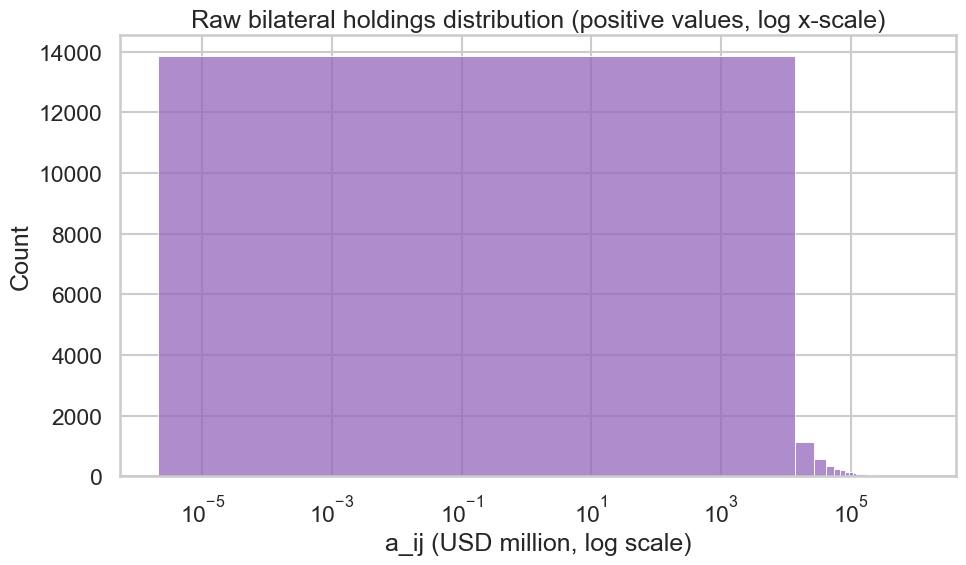

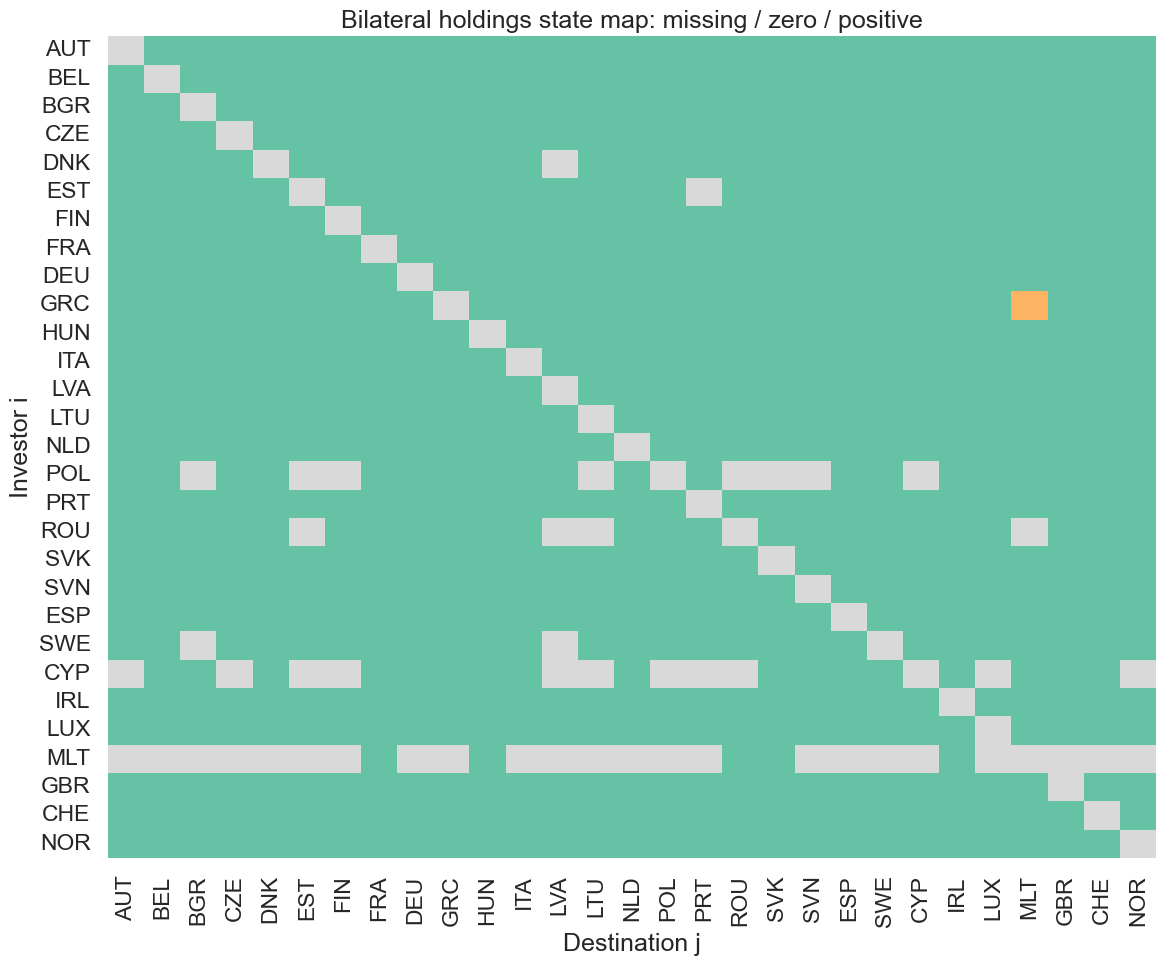

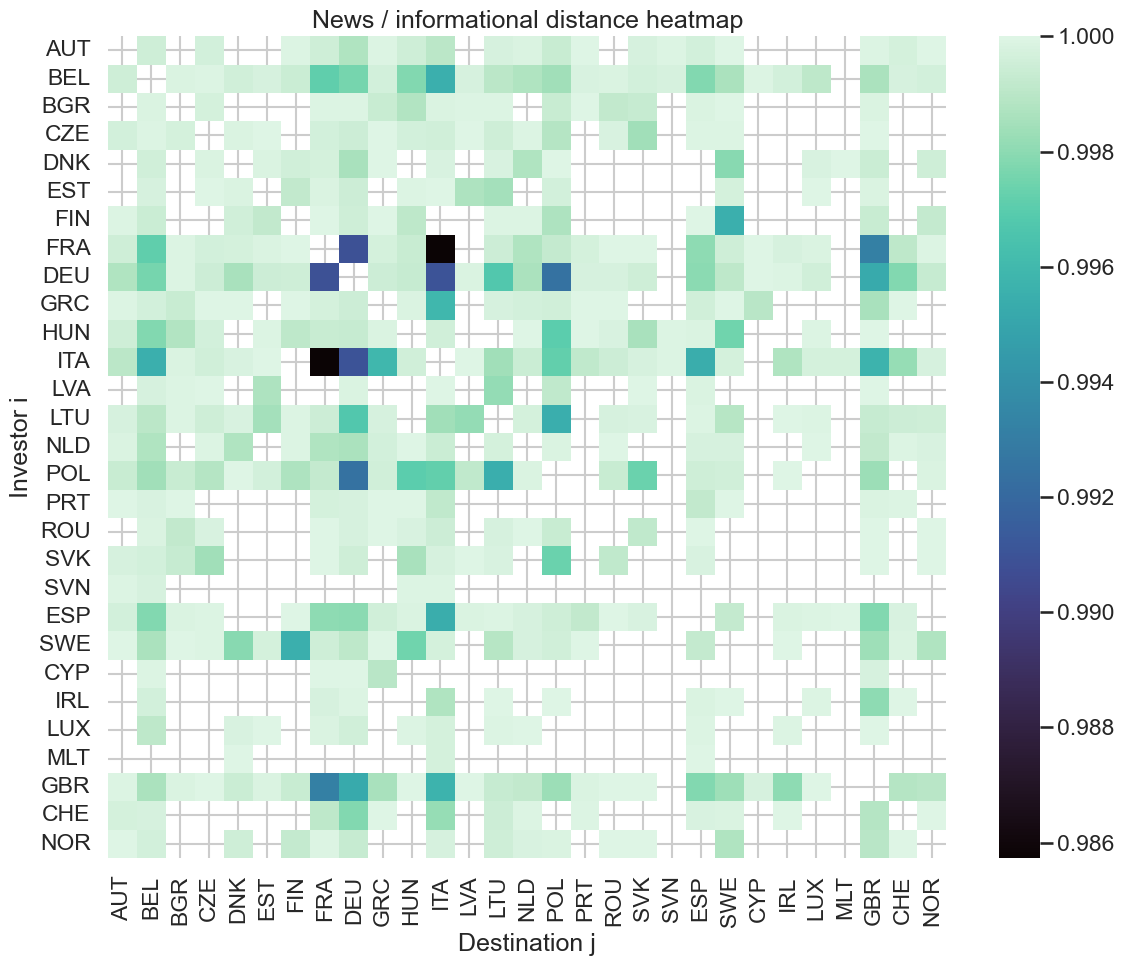

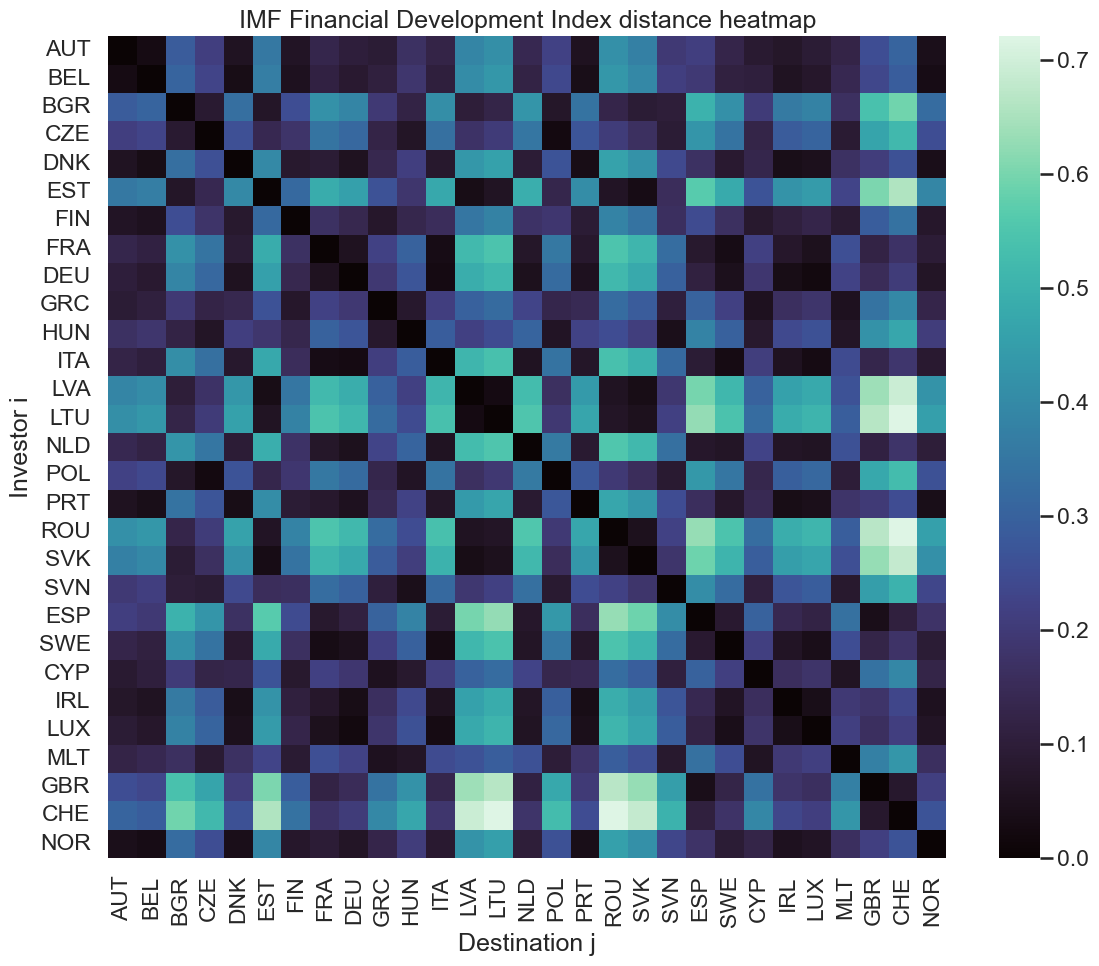

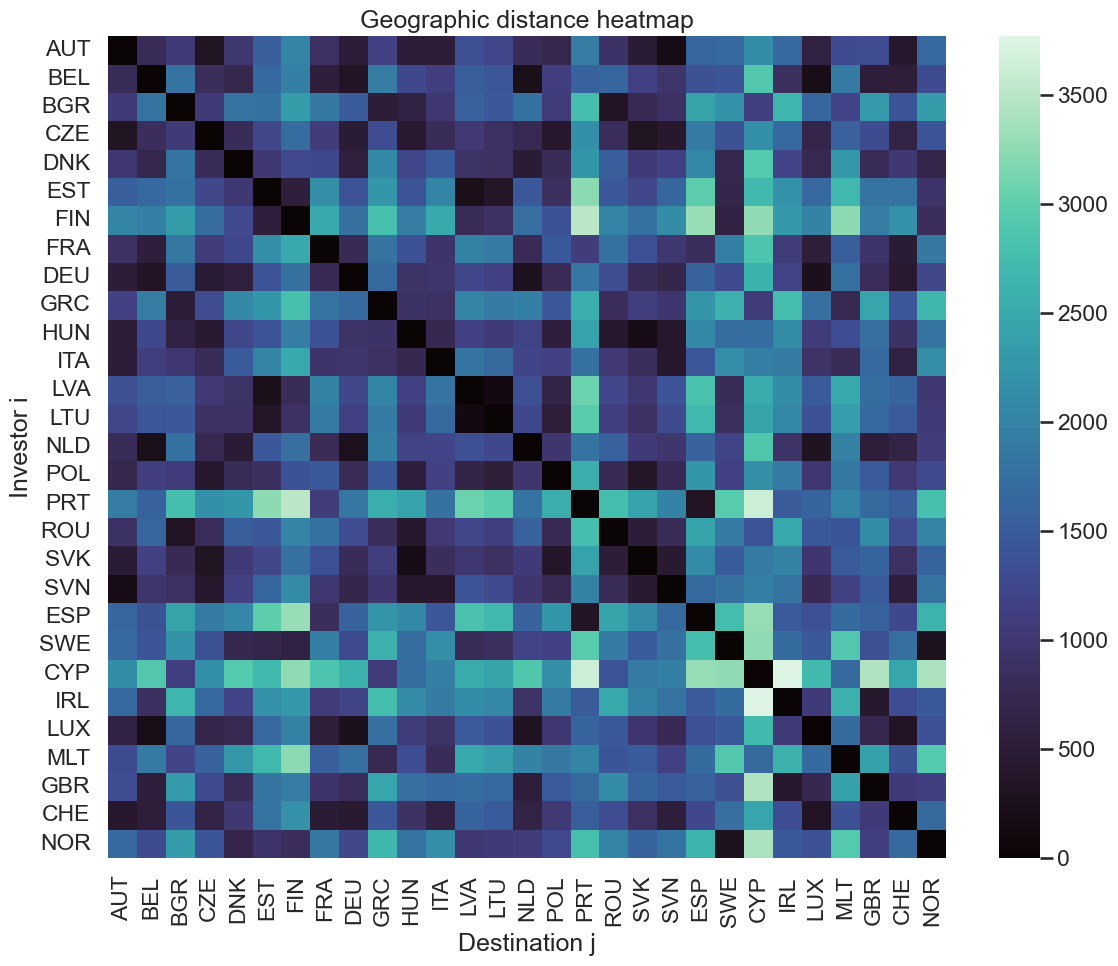

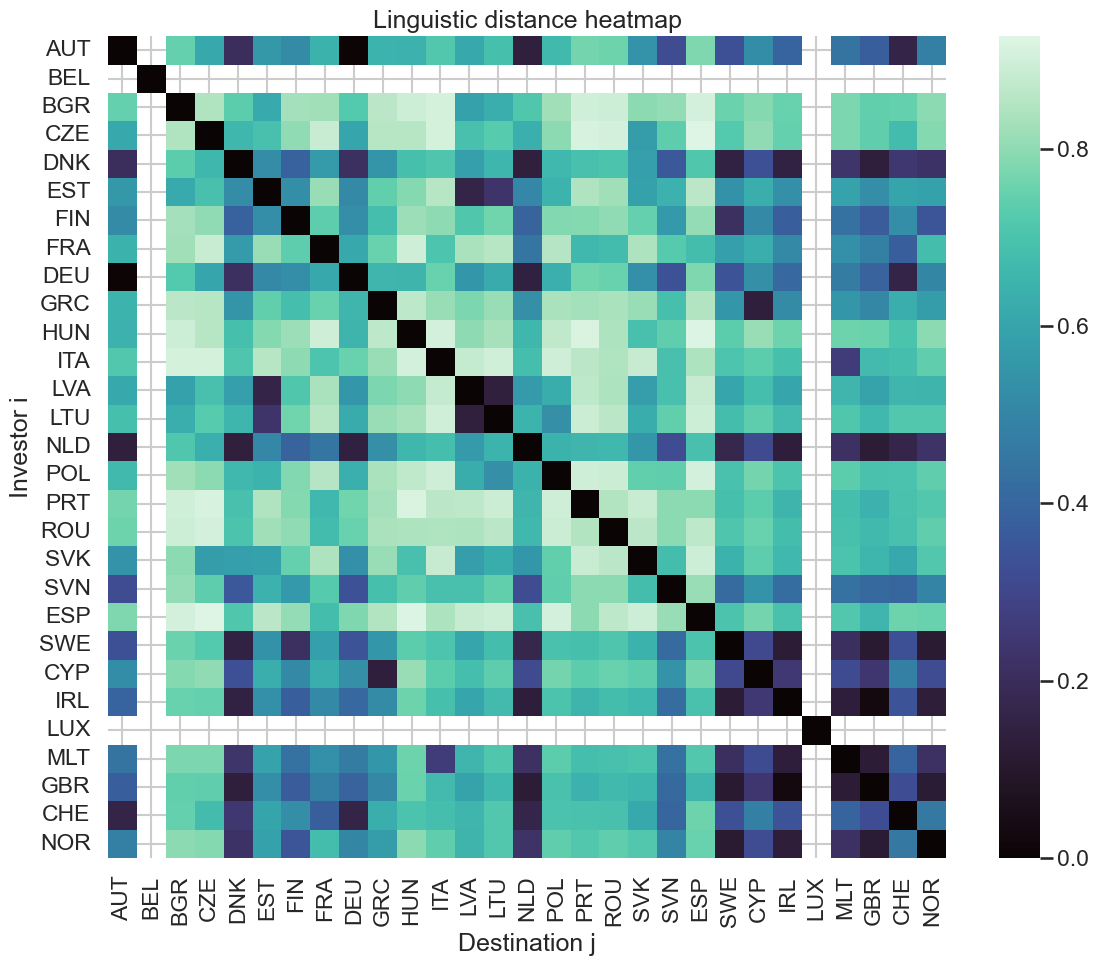

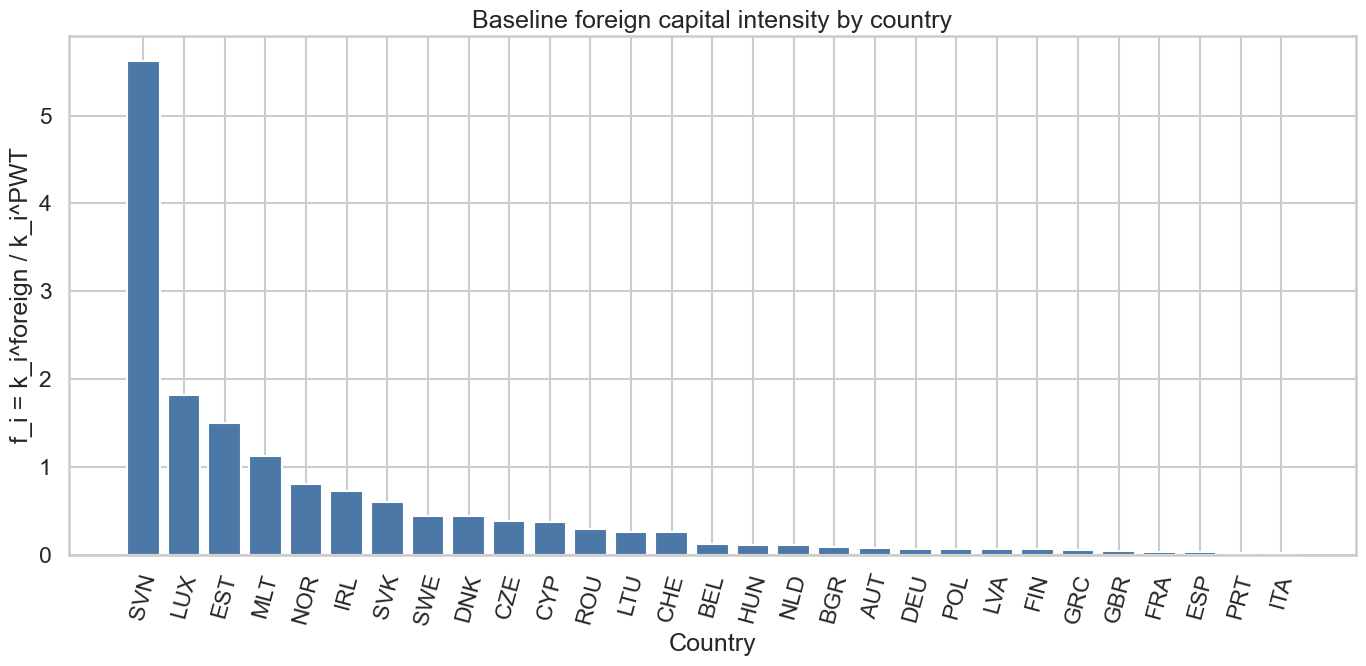

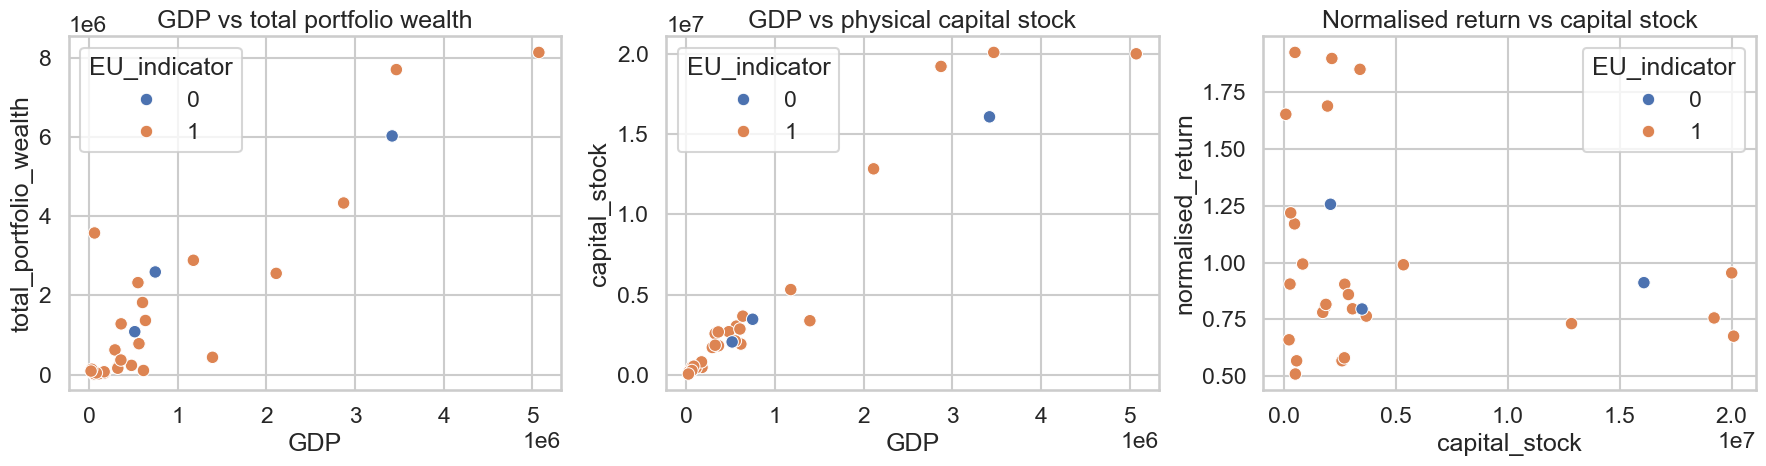

Saved figures to: /Users/jesper/Desktop/CBS/Thesis 1/Jesper-Liedholm-Thesis-Code/imgs/v4-data


In [8]:
from matplotlib.colors import ListedColormap

# A) Raw bilateral holdings distribution (log-x scale)
raw_pos = df_country.loc[df_country['a_ij'] > 0, 'a_ij']
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(raw_pos, bins=80, ax=ax, color='#9467bd')
ax.set_xscale('log')
ax.set_title('Raw bilateral holdings distribution (positive values, log x-scale)')
ax.set_xlabel('a_ij (USD million, log scale)')
fig.tight_layout()
fig.savefig(OUT_DIR / 'A1_raw_holdings_distribution_logx.png', dpi=220)
plt.show()

# B) Bilateral holdings missingness/state heatmap
state = A.copy()
state = state.where(~state.isna(), -1)
state = state.where(~(state == 0), 0)
state = state.where(~(state > 0), 1)
# map: -1 missing, 0 zero, 1 positive
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(state, cmap=ListedColormap(['#d9d9d9', '#fdb462', '#66c2a5']), cbar=False, ax=ax)
ax.set_title('Bilateral holdings state map: missing / zero / positive')
ax.set_xlabel('Destination j')
ax.set_ylabel('Investor i')
fig.tight_layout()
fig.savefig(OUT_DIR / 'A2_bilateral_state_heatmap.png', dpi=220)
plt.show()

# C) News, IMF Financial Development Index-distance, geographic, linguistic heatmaps
friction_heatmaps = [
    ('d_num_articles', 'A3_news_distance_heatmap.png', 'News / informational distance heatmap'),
    ('d_financial_development_index', 'A4_imf_financial_development_index_distance_heatmap.png', 'IMF Financial Development Index distance heatmap'),
    ('d_geo', 'A5_geographic_distance_heatmap.png', 'Geographic distance heatmap'),
    ('d_ling', 'A6_linguistic_distance_heatmap.png', 'Linguistic distance heatmap'),
]

for col, fname, ttl in friction_heatmaps:
    if col not in base.columns and col not in df_country.columns:
        print(f'Skipping {ttl} — column {col} not in data')
        continue

    # For IMF financial development distance, use all years (pair mean)
    # to avoid empty base-year heatmaps when the base year has sparse coverage.
    src = df_country if col == 'd_financial_development_index' else base

    if col not in src.columns:
        print(f'Skipping {ttl} — column {col} not in selected source data')
        continue

    M = src.pivot_table(index='iso3_i', columns='iso3_j', values=col, aggfunc='mean').reindex(index=SIM_COUNTRIES, columns=SIM_COUNTRIES)

    if M.isna().all().all():
        print(f'Skipping {ttl} — all values are missing after construction')
        continue

    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(M, cmap='mako', ax=ax)
    ax.set_title(ttl)
    ax.set_xlabel('Destination j')
    ax.set_ylabel('Investor i')
    fig.tight_layout()
    fig.savefig(OUT_DIR / fname, dpi=220)
    plt.show()

# D) Foreign capital intensity bar chart
f_plot = country_baseline_table[['country', 'foreign_capital_intensity']].dropna().sort_values('foreign_capital_intensity', ascending=False)
if len(f_plot) > 0:
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.bar(f_plot['country'], f_plot['foreign_capital_intensity'], color='#4c78a8')
    ax.set_title('Baseline foreign capital intensity by country')
    ax.set_xlabel('Country')
    ax.set_ylabel('f_i = k_i^foreign / k_i^PWT')
    ax.tick_params(axis='x', rotation=75)
    fig.tight_layout()
    fig.savefig(OUT_DIR / 'A7_foreign_capital_intensity_bar.png', dpi=220)
    plt.show()

# E) Macro scatterplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
tmp = country_baseline_table.copy()
sns.scatterplot(data=tmp, x='GDP', y='total_portfolio_wealth', hue='EU_indicator', ax=axes[0])
axes[0].set_title('GDP vs total portfolio wealth')
sns.scatterplot(data=tmp, x='GDP', y='capital_stock', hue='EU_indicator', ax=axes[1])
axes[1].set_title('GDP vs physical capital stock')
sns.scatterplot(data=tmp, x='capital_stock', y='normalised_return', hue='EU_indicator', ax=axes[2])
axes[2].set_title('Normalised return vs capital stock')
fig.tight_layout()
fig.savefig(OUT_DIR / 'A8_macro_scatterplots.png', dpi=220)
plt.show()

print('Saved figures to:', OUT_DIR.resolve())


## Appendix figures

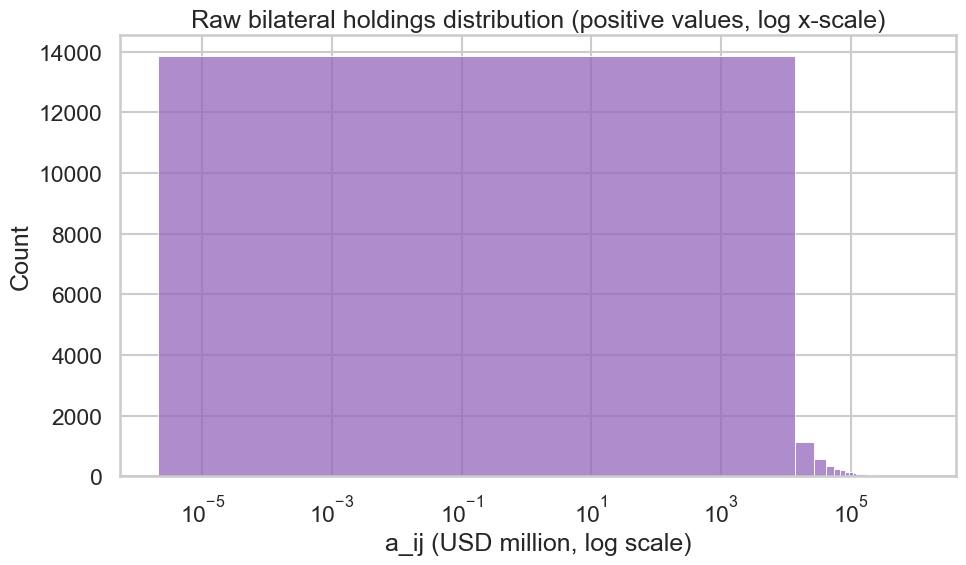

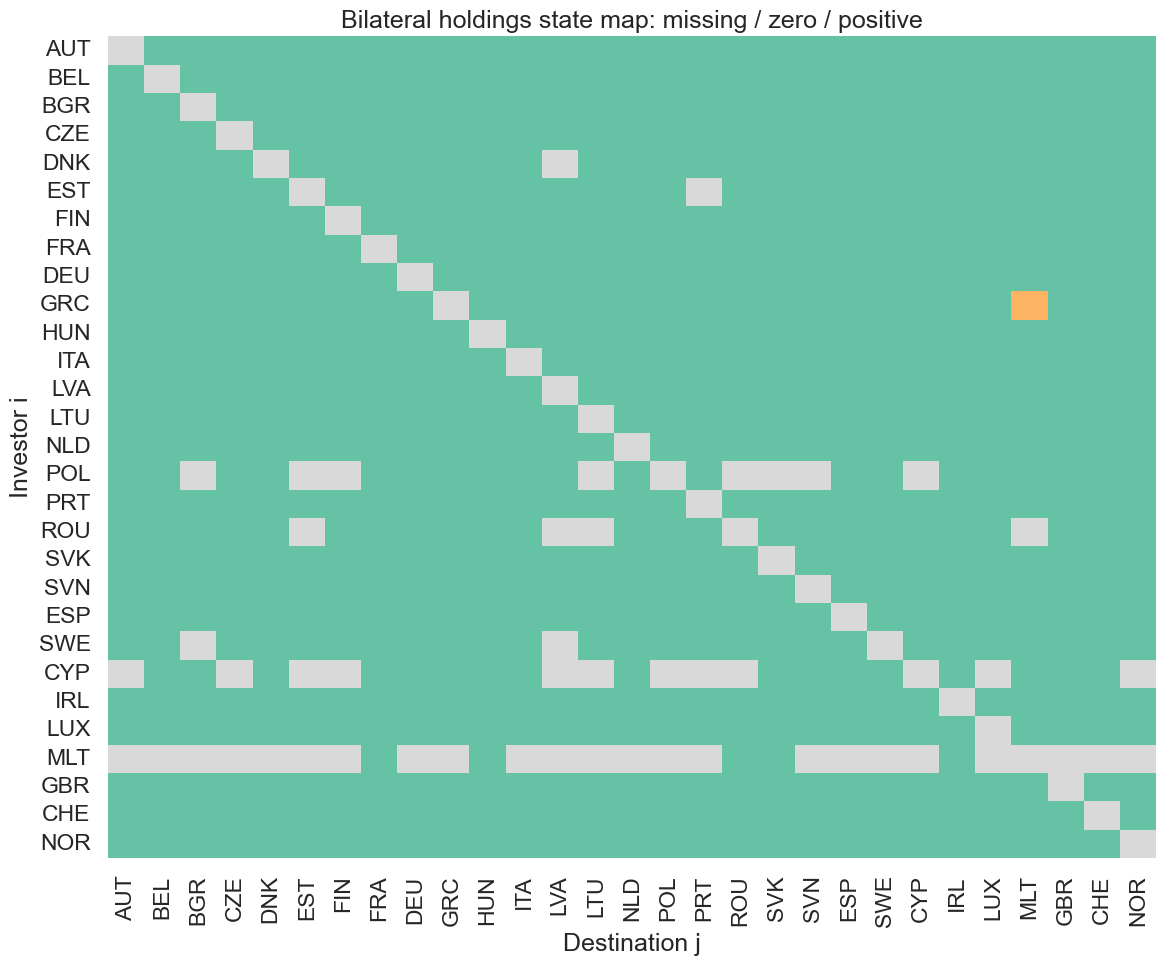

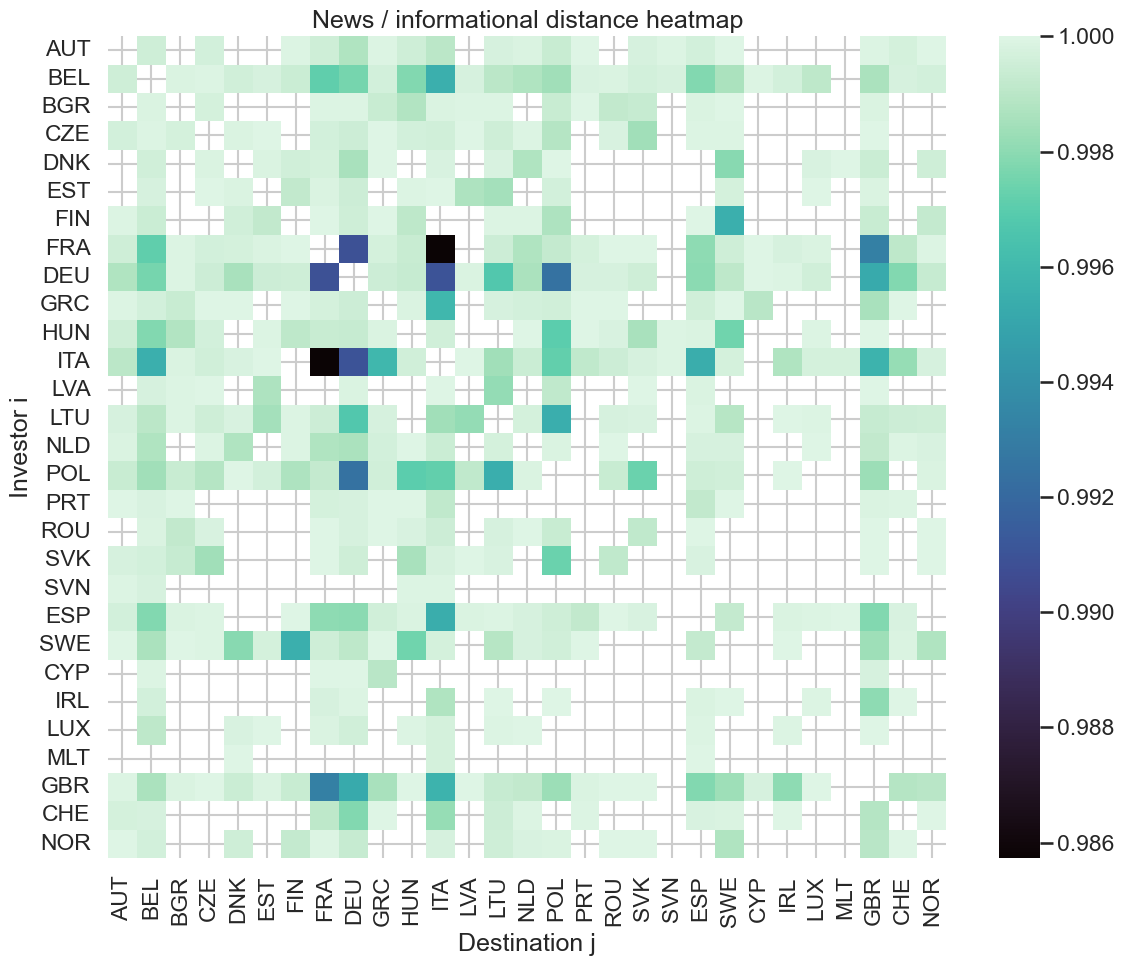

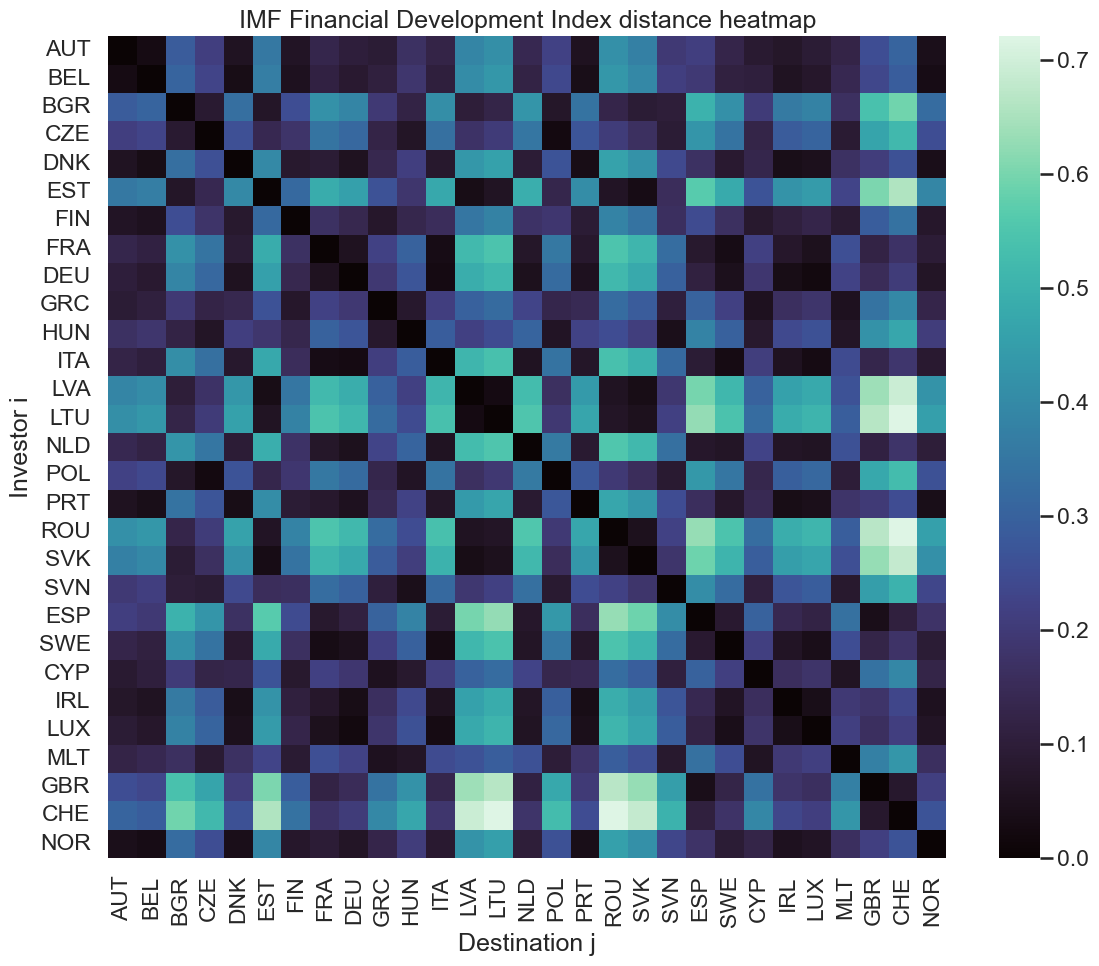

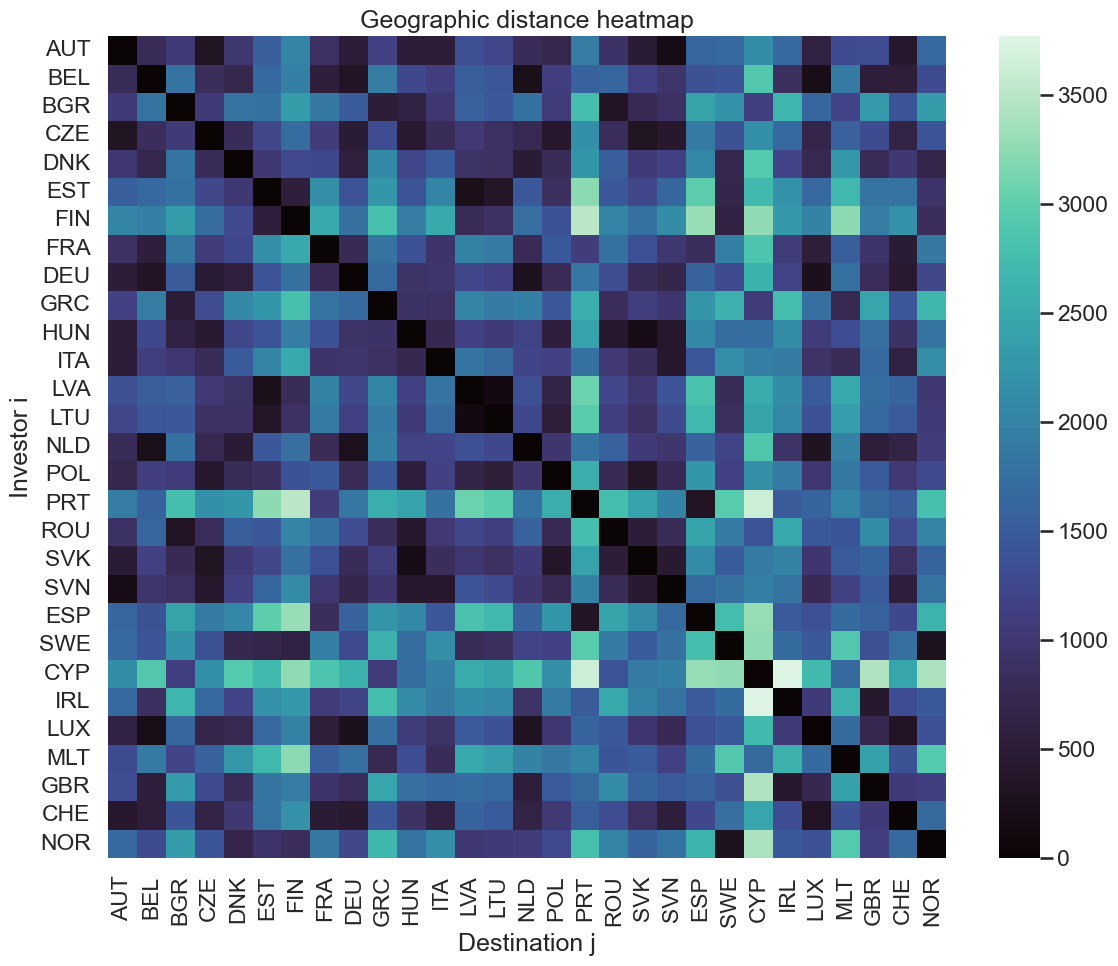

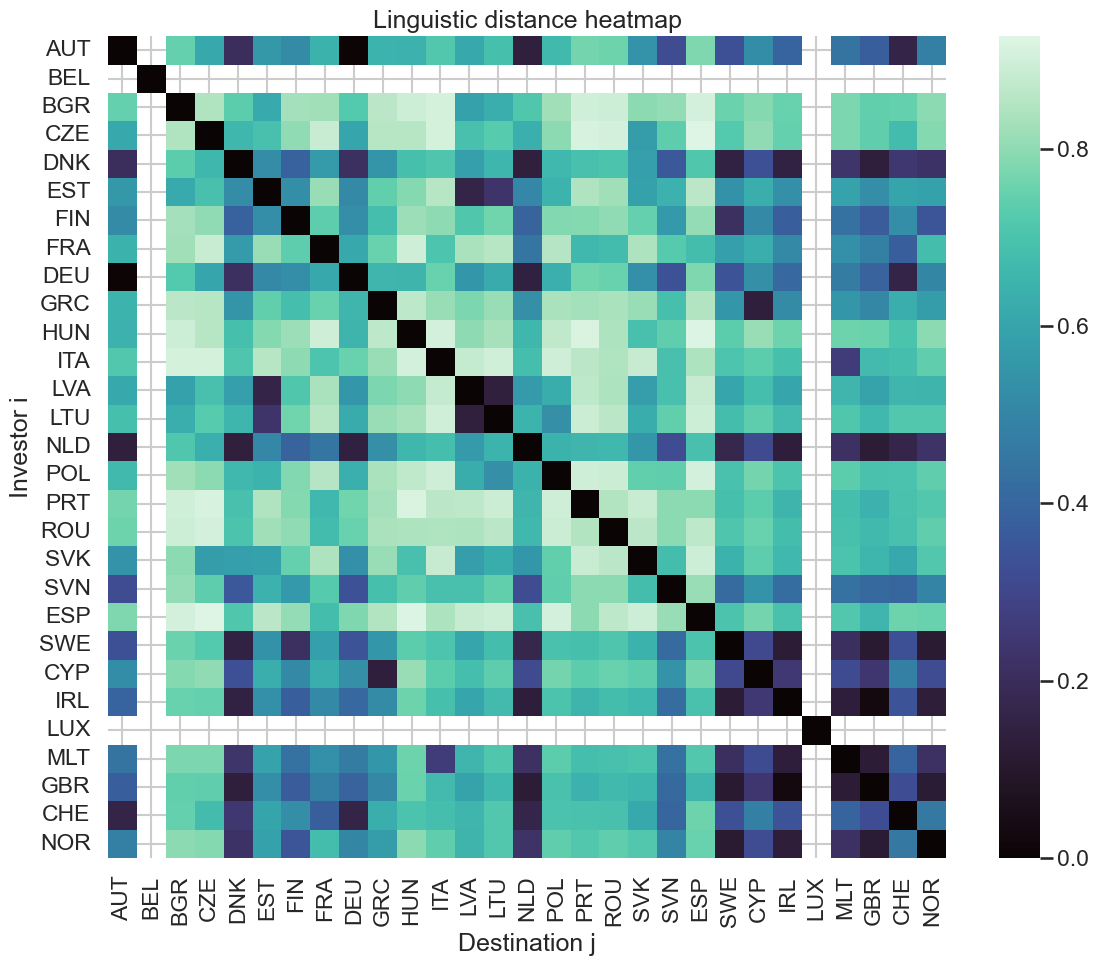

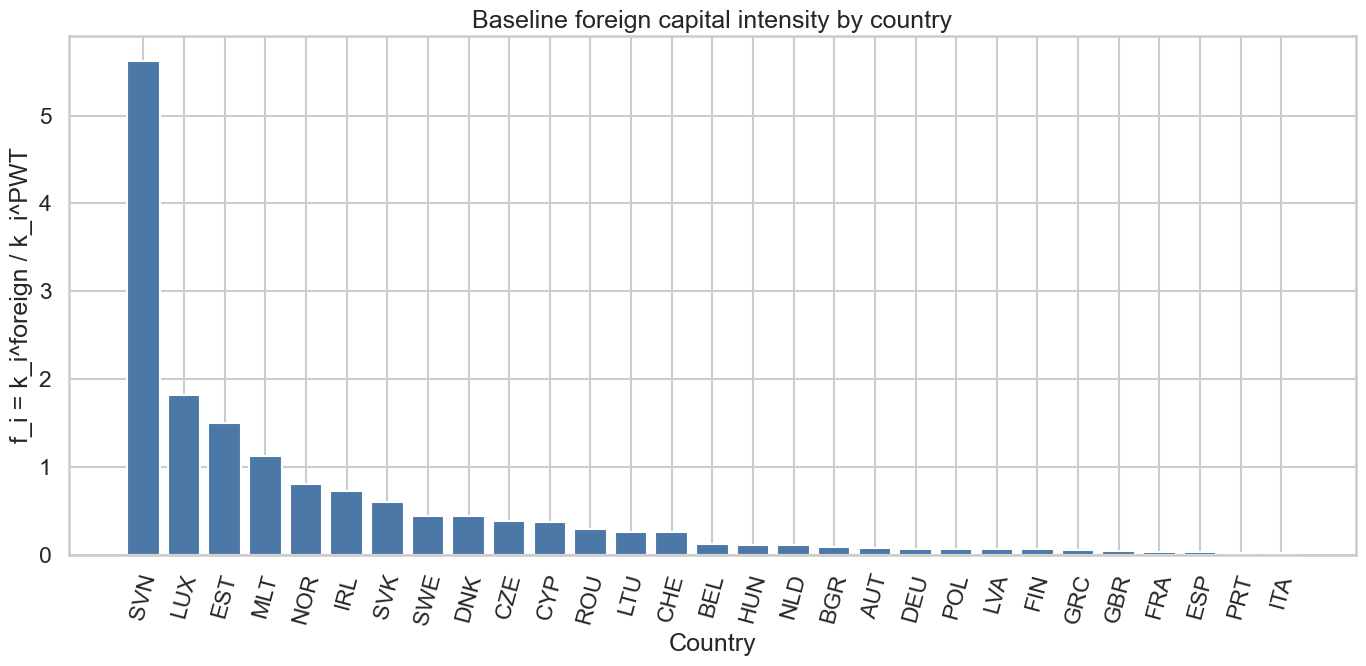

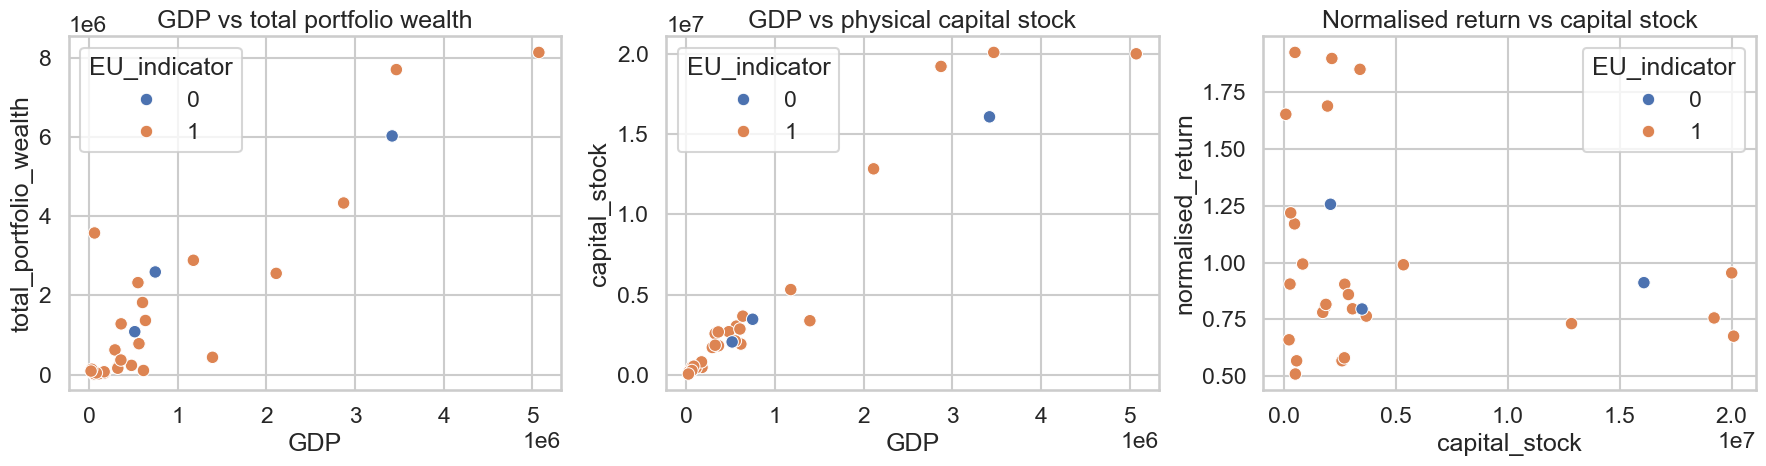

Saved figures to: /Users/jesper/Desktop/CBS/Thesis 1/Jesper-Liedholm-Thesis-Code/imgs/v4-data


In [9]:
from matplotlib.colors import ListedColormap

# A) Raw bilateral holdings distribution (log-x scale)
raw_pos = df_country.loc[df_country['a_ij'] > 0, 'a_ij']
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(raw_pos, bins=80, ax=ax, color='#9467bd')
ax.set_xscale('log')
ax.set_title('Raw bilateral holdings distribution (positive values, log x-scale)')
ax.set_xlabel('a_ij (USD million, log scale)')
fig.tight_layout()
fig.savefig(OUT_DIR / 'A1_raw_holdings_distribution_logx.png', dpi=220)
plt.show()

# B) Bilateral holdings missingness/state heatmap
state = A.copy()
state = state.where(~state.isna(), -1)
state = state.where(~(state == 0), 0)
state = state.where(~(state > 0), 1)
# map: -1 missing, 0 zero, 1 positive
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(state, cmap=ListedColormap(['#d9d9d9', '#fdb462', '#66c2a5']), cbar=False, ax=ax)
ax.set_title('Bilateral holdings state map: missing / zero / positive')
ax.set_xlabel('Destination j')
ax.set_ylabel('Investor i')
fig.tight_layout()
fig.savefig(OUT_DIR / 'A2_bilateral_state_heatmap.png', dpi=220)
plt.show()

# C) News, IMF Financial Development Index-distance, geographic, linguistic heatmaps
for col, fname, ttl in [
    ('d_num_articles', 'A3_news_distance_heatmap.png', 'News / informational distance heatmap'),
    ('d_financial_development_index', 'A4_imf_financial_development_index_distance_heatmap.png', 'IMF Financial Development Index distance heatmap'),
    ('d_geo', 'A5_geographic_distance_heatmap.png', 'Geographic distance heatmap'),
    ('d_ling', 'A6_linguistic_distance_heatmap.png', 'Linguistic distance heatmap'),
]:
    if col not in base.columns and col not in df_country.columns:
        print(f'Skipping {ttl} — column {col} not in data')
        continue

    src = df_country if col == 'd_financial_development_index' else base

    if col not in src.columns:
        print(f'Skipping {ttl} — column {col} not in selected source data')
        continue

    M = src.pivot_table(index='iso3_i', columns='iso3_j', values=col, aggfunc='mean').reindex(index=SIM_COUNTRIES, columns=SIM_COUNTRIES)

    if M.isna().all().all():
        print(f'Skipping {ttl} — all values are missing after construction')
        continue

    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(M, cmap='mako', ax=ax)
    ax.set_title(ttl)
    ax.set_xlabel('Destination j')
    ax.set_ylabel('Investor i')
    fig.tight_layout()
    fig.savefig(OUT_DIR / fname, dpi=220)
    plt.show()

# D) Foreign capital intensity bar chart
f_plot = country_baseline_table[['country', 'foreign_capital_intensity']].dropna().sort_values('foreign_capital_intensity', ascending=False)
if len(f_plot) > 0:
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.bar(f_plot['country'], f_plot['foreign_capital_intensity'], color='#4c78a8')
    ax.set_title('Baseline foreign capital intensity by country')
    ax.set_xlabel('Country')
    ax.set_ylabel('f_i = k_i^foreign / k_i^PWT')
    ax.tick_params(axis='x', rotation=75)
    fig.tight_layout()
    fig.savefig(OUT_DIR / 'A7_foreign_capital_intensity_bar.png', dpi=220)
    plt.show()

# E) Macro scatterplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
tmp = country_baseline_table.copy()
sns.scatterplot(data=tmp, x='GDP', y='total_portfolio_wealth', hue='EU_indicator', ax=axes[0])
axes[0].set_title('GDP vs total portfolio wealth')
sns.scatterplot(data=tmp, x='GDP', y='capital_stock', hue='EU_indicator', ax=axes[1])
axes[1].set_title('GDP vs physical capital stock')
sns.scatterplot(data=tmp, x='capital_stock', y='normalised_return', hue='EU_indicator', ax=axes[2])
axes[2].set_title('Normalised return vs capital stock')
fig.tight_layout()
fig.savefig(OUT_DIR / 'A8_macro_scatterplots.png', dpi=220)
plt.show()

print('Saved figures to:', OUT_DIR.resolve())


## Suggested thesis placement

**Main text:**
1. Data sources and variable mapping table
2. Sample construction table
3. Main descriptive statistics table
4. Missingness and treatment table
5. Home-bias table or country bar chart
6. Distribution of log(1+a_ij)
7. Four-panel friction distributions
8. Correlation heatmap
9. Observed portfolio-share heatmap

**Appendix:**
- Raw holdings distribution
- Bilateral state/missingness heatmap
- News / KAOPEN / geographic / linguistic heatmaps
- Foreign capital intensity bar chart
- Macro scatterplots